Libraries

In [426]:
import numpy as np
import scipy.linalg as la
from scipy.linalg import solve
import matplotlib.pyplot as plt
import pandas as pd
from numpy.linalg import inv, norm, eigvals
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import norm as sparse_norm

Helper Functions

In [123]:
def print_matrix(matrix):
    for row in matrix:
        print(" ".join(map(str, row)))

def generate_random_vector(size, min_value=1, max_value=100):
    if size <= 0:
        raise ValueError("Size must be a positive integer.")
    return np.random.randint(min_value, max_value + 1, size)

def find_min_max(vector):
    if not isinstance(vector, np.ndarray):
        raise TypeError("Input must be a NumPy array.")
    if vector.size == 0:
        raise ValueError("Vector must not be empty.")
    
    smallest = vector.min()
    largest = vector.max()
    
    return smallest, largest

def cond_and_radius(A):
    min_eigen, max_eigen = find_min_max(A)
    return (max_eigen/min_eigen), (max_eigen - min_eigen)

Algorithms (RD, SD, CG)

In [ ]:
def richardson(Lambda, b, x_0, x_star= None, tol = 1e-06, Max_ITER = 1000):
    x_k = x_0
    r_0 = b - (Lambda*x_0)              # This does dense Matrix-vector BLAS1 update in Python

    if(la.norm(r_0) == 0):
        print("Initial Guess is a solution!")
        return x_k, [0], [0], [0]

    r_k = r_0
    
    errors = np.zeros(Max_ITER+1)
    residuals = np.zeros(Max_ITER+1)
    errors[0] = la.norm(x_0 - x_star)
    residuals[0] = la.norm(r_0)

    lambda_min, lambda_max = find_min_max(Lambda)
    alpha = 2/(lambda_min+lambda_max)

    num_of_iterations = 0
    while ( (la.norm(r_k)/la.norm(r_0) > tol) and num_of_iterations < Max_ITER):
        x_k = x_k + (alpha*r_k)
        r_k = r_k - alpha*(Lambda*r_k)
        num_of_iterations += 1
        errors[num_of_iterations] = la.norm(x_k - x_star)
        residuals[num_of_iterations] = la.norm(r_k)

    return x_k, num_of_iterations, errors, residuals


def steepest_descent(Lambda, b, x_0, x_star= None, tol = 1e-06, Max_ITER = 1000):
    x_k = x_0
    r_0 = b - (Lambda*x_0)

    if(la.norm(r_0) == 0):
        print("Initial Guess is a solution!")
        return x_k, [0], [0], [0]
    
    v_0 = Lambda*r_0
    v_k = v_0
    r_k = r_0
    
    errors = np.zeros(Max_ITER+1)
    residuals = np.zeros(Max_ITER+1)
    errors[0] = la.norm(x_0 - x_star)
    residuals[0] = la.norm(r_0)


    num_of_iterations = 0
    while ( (la.norm(r_k)/la.norm(r_0) > tol) and num_of_iterations < Max_ITER):
        alpha = (np.dot(r_k, r_k)) / (np.dot(r_k,v_k))
        x_k = x_k + (alpha*r_k)
        r_k = r_k - (alpha*v_k)
        v_k = Lambda*r_k

        num_of_iterations += 1
        errors[num_of_iterations] = la.norm(x_k - x_star)
        residuals[num_of_iterations] = la.norm(r_k)

    return x_k, num_of_iterations, errors, residuals

def conjugate_gradient(Lambda, b, x_0, x_star= None, tol = 1e-06, Max_ITER = 1000):
    x_k = x_0
    r_0 = b - (Lambda*x_0)
    if(la.norm(r_0) == 0):
        print("Initial Guess is a solution!")
        return x_k, [0], [0], [0]
    
    r_k = r_0
    d = r_0
    sigma = np.dot(r_0, r_0) 
    
    errors = np.zeros(Max_ITER+1)
    residuals = np.zeros(Max_ITER+1)
    errors[0] = la.norm(x_0 - x_star)
    residuals[0] = la.norm(r_0)

    num_of_iterations = 0
    while ( (la.norm(r_k)/la.norm(r_0) > tol) and num_of_iterations < Max_ITER):
        v = Lambda*d
        mu = np.dot(d,v) 
        alpha = sigma / mu

        x_k = x_k + alpha*(d)
        r_k = r_k - alpha*(v)
        sigma_old = sigma
        sigma = np.dot(r_k, r_k)
        beta = sigma / sigma_old
        d = r_k + beta*(d)

        num_of_iterations += 1
        errors[num_of_iterations] = la.norm(x_k - x_star)
        residuals[num_of_iterations] = la.norm(r_k)

    return x_k, num_of_iterations, errors, residuals


Error Testing Helper Functions

In [ ]:
def generate_convergence_grid(num_RF, error_RF, residuals_RF,
                              num_SD, error_SD, residuals_SD,
                              num_CG, error_CG, residuals_CG,
                              save_image=False, output_image="convergence_grid.png"):
    methods = [
        ("Richardson", num_RF, error_RF, residuals_RF),
        ("Steepest Descent", num_SD, error_SD, residuals_SD),
        ("Conjugate Gradient", num_CG, error_CG, residuals_CG)
    ]
    
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    
    for row, (method, num, error, residuals) in enumerate(methods):
        # Error 
        axes[row, 0].plot(range(num+1), error[:num+1], color='blue', linewidth=1.5)
        axes[row, 0].set_title(f"{method} - Error")
        axes[row, 0].set_xlabel("Iteration")
        axes[row, 0].set_ylabel("Error")
        axes[row, 0].grid(True, which='both', linestyle='--', linewidth=0.5)
        
     
        axes[row, 1].plot(range(num+1), residuals[:num+1], color='red', linewidth=1.5)
        axes[row, 1].set_title(f"{method} - Residual")
        axes[row, 1].set_xlabel("Iteration")
        axes[row, 1].set_ylabel("Residual")
        axes[row, 1].grid(True, which='both', linestyle='--', linewidth=0.5)

    plt.tight_layout()
    
    if save_image:

        plt.savefig(output_image, bbox_inches='tight')
        print(f"Grid of convergence plots saved as '{output_image}'.")

    plt.show()

def save_problem_info_as_image(problem_info, output_image="problem_info.png"):

    fig, ax = plt.subplots(figsize=(8, 4))  
    ax.axis('off')  # Hide axes
    ax.text(0.5, 0.5, problem_info, fontsize=14, ha='center', va='center', wrap=True)
    plt.savefig(output_image, bbox_inches='tight')
    print(f"Problem information saved as '{output_image}'.")
    plt.close(fig)

def save_table_as_image(df, output_image="comparison_table.png"):
    df["Initial Error"] = df["Initial Error"].apply(lambda x: f"{x:.2e}")
    df["Final Error"] = df["Final Error"].apply(lambda x: f"{x:.2e}")
    df["Residual"] = df["Residual"].apply(lambda x: f"{x:.2e}")

    fig, ax = plt.subplots(figsize=(12, 6)) 
    ax.axis('tight')
    ax.axis('off')

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='center',
        loc='center',
        colColours=["#f1f1f2"] * len(df.columns)
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(len(df.columns))))  #

    plt.savefig(output_image, bbox_inches='tight')
    print(f"Comparison table saved as '{output_image}'.")
    plt.close(fig)


def save_damping_ratio_plots(num_RF, error_RF, cond_RF, num_SD, error_SD, cond_SD, num_CG, error_CG, cond_CG, save_image=False, output_image="damping_ratios.png"):
    methods = [
        ("Richardson", num_RF, error_RF, cond_RF, (cond_RF - 1) / (cond_RF + 1)),
        ("Steepest Descent", num_SD, error_SD, cond_SD, (cond_SD - 1) / (cond_SD + 1)),
        ("Conjugate Gradient", num_CG, error_CG, cond_CG, (cond_CG**0.5 - 1) / (cond_CG**0.5 + 1))
    ]
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))

    for row, (method, num, error, cond, upper_bound) in enumerate(methods):
        # Compute error ratios
        ratios = [error[i+1] / error[i] for i in range(1, num)]

        # Plot ratios
        axes[row].plot(range(1, len(ratios)+1), ratios, label=f"{method} Error Ratios", color="blue")
        axes[row].axhline(y=upper_bound, color="red", linestyle="--", label=f"Upper Bound: {upper_bound:.2e}")
        
        # Add additional context
        axes[row].set_title(f"{method} - Damping Ratios")
        axes[row].set_xlabel("Iteration")
        axes[row].set_ylabel("Error Ratio")
        axes[row].legend(loc="upper right", fontsize=10)
        axes[row].grid(True, linestyle="--", linewidth=0.5)

    plt.tight_layout()

    if save_image:
        plt.savefig(output_image, bbox_inches="tight")
        print(f"Damping ratio plots saved as '{output_image}'.")
    plt.show()


In [ ]:
def generate_results(A, b, guess, x, tol, max_iter):
    size = len(b)

    # Run Richardson
    output_RF, num_RF, error_RF, residuals_RF = richardson(A, b, guess, x, tol, max_iter)
    total_work_RF = (2 * size + 2) + num_RF * (5 * size)

    # Rn Steepest Descent
    output_SD, num_SD, error_SD, residuals_SD = steepest_descent(A, b, guess, x, tol, max_iter)
    total_work_SD = (3 * size) + num_SD * (9 * size - 1)

    # run Conjugate Gradient
    output_CG, num_CG, error_CG, residuals_CG = conjugate_gradient(A, b, guess, x, tol, max_iter)
    total_work_CG = (4 * size - 1) + num_CG * (11 * size)

    results = [
        ["Richardson", num_RF < max_iter, num_RF, error_RF[0], error_RF[num_RF], residuals_RF[num_RF], total_work_RF],
        ["Steepest Descent", num_SD < max_iter, num_SD, error_SD[0], error_SD[num_SD], residuals_SD[num_SD], total_work_SD],
        ["Conjugate Gradient", num_CG < max_iter, num_CG, error_CG[0], error_CG[num_CG], residuals_CG[num_CG], total_work_CG]
    ]

    results_df = pd.DataFrame(
        results,
        columns=[
            "Algorithm",
            "Convergence (True/False)",
            "Iterations (num)",
            "Initial Error",
            "Final Error",
            "Residual",
            "Total Work"
        ]
    )
    return results_df





def generate_results_and_save_outputs(A, b, guess, x, tol, max_iter, save_outputs=False,
                                      table_image="comparison_table.png", 
                                      grid_image="convergence_plots_grid.png", 
                                      info_image="problem_info.png", 
                                      damping_image="damping_ratios.png"):
    cond_number, spectral_radius = cond_and_radius(A)
    size = len(b)
    results = []

    # Richardson
    output_RF, num_RF, error_RF, residuals_RF = richardson(A, b, guess, x, tol, max_iter)
    total_work_RF = (2 * size + 2) + num_RF * (5 * size)
    results.append(["Richardson", num_RF < max_iter, num_RF, error_RF[0], error_RF[num_RF], residuals_RF[num_RF], total_work_RF])

    # Steepest Descent
    output_SD, num_SD, error_SD, residuals_SD = steepest_descent(A, b, guess, x, tol, max_iter)
    total_work_SD = (3 * size) + num_SD * (9 * size - 1)
    results.append(["Steepest Descent", num_SD < max_iter, num_SD, error_SD[0], error_SD[num_SD], residuals_SD[num_SD], total_work_SD])

    # Conjugate Gradient
    output_CG, num_CG, error_CG, residuals_CG = conjugate_gradient(A, b, guess, x, tol, max_iter)
    total_work_CG = (4 * size - 1) + num_CG * (11 * size)
    results.append(["Conjugate Gradient", num_CG < max_iter, num_CG, error_CG[0], error_CG[num_CG], residuals_CG[num_CG], total_work_CG])

    df = pd.DataFrame(
        results,
        columns=[
            "Algorithm",
            "Convergence (True/False)",
            "Iterations (num)",
            "Initial Error",
            "Final Error",
            "Residual",
            "Total Work"
        ]
    )

    if size > 25:
        problem_info = (
            f"Condition Number of the System: {cond_number}\n"
            f"Spectral Radius of the System: {spectral_radius}\n"
            f"Size of Problem: {size}\n"
            f"Tolerance (tol): {tol}\n"
        )
    else:
        problem_info = (
            f"Condition Number of the System: {cond_number}\n"
            f"Spectral Radius of the System: {spectral_radius}\n"
            f"Size of Problem: {size}\n"
            f"True Solution (x): {x}\n"
            f"Initial Guess: {guess}\n"
            f"Tolerance (tol): {tol}\n"
        )
    print(problem_info)
    print(df)

    if save_outputs:
        save_problem_info_as_image(problem_info, output_image=info_image)

        save_table_as_image(df, output_image=table_image)

        generate_convergence_grid(
            num_RF, error_RF, residuals_RF,
            num_SD, error_SD, residuals_SD,
            num_CG, error_CG, residuals_CG,
            save_image=True,
            output_image=grid_image
        )

        save_damping_ratio_plots(
            num_RF, error_RF, cond_number,
            num_SD, error_SD, cond_number,
            num_CG, error_CG, cond_number,
            save_image=True,
            output_image=damping_image
        )
    else:
        generate_convergence_grid(
            num_RF, error_RF, residuals_RF,
            num_SD, error_SD, residuals_SD,
            num_CG, error_CG, residuals_CG,
            save_image=False
        )
        save_damping_ratio_plots(
            num_RF, error_RF, cond_number,
            num_SD, error_SD, cond_number,
            num_CG, error_CG, cond_number,
            save_image=False
        )

    return df

In [ ]:
def generate_vector(vector_size=100, min_k=2, max_k=10, value_range=(0.1, 10)):
    # Choose the number of distinct values (k)
    k = np.random.randint(min_k, max_k + 1)

    # Generate k distinct positive values within the specified range
    distinct_values = np.random.uniform(value_range[0], value_range[1], k)

    # Generate random multiplicities that sum to vector_size
    multiplicities = np.random.multinomial(vector_size, [1/k] * k)

    # Generate the vector by repeating each value based on its multiplicity
    vector = np.concatenate([np.repeat(value, m) for value, m in zip(distinct_values, multiplicities)])

    # Shuffle the vector to randomize the order
    np.random.shuffle(vector)

    return vector, distinct_values, multiplicities

def generate_table_image(distinct_values, multiplicities, output_file="table.png"):
    data = {
        "Eigenvalue": distinct_values,
        "Multiplicity": multiplicities
    }
    df = pd.DataFrame(data)
    fig, ax = plt.subplots(figsize=(6, len(distinct_values) * 0.5 + 1))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(len(df.columns))))
    plt.savefig(output_file, bbox_inches='tight')
    plt.close()
def generate_cloud_vector(distinct_values, multiplicities, std_dev=0.5):
    cloud_vector = np.concatenate([
        np.random.normal(loc=value, scale=std_dev, size=m)
        for value, m in zip(distinct_values, multiplicities)
    ])
    np.random.shuffle(cloud_vector)
    return cloud_vector



Interactive Testing (Uniform Randomizer)

In [ ]:
dimension = 100          # This defines work storage = 3*dimension
max_A = 40            # Controlling maximum eigenvalue of the system
min_A = 2              # Has to be > 1 to ensure positive values (A is spd)

A = generate_random_vector(dimension, min_A, max_A)
x = generate_random_vector(dimension, -max_A, max_A)

b = A*x

guess = generate_random_vector(dimension, -max_A, max_A)

# Convergence criterion
max_iter = 10000
tol = 1e-08

results = generate_results_and_save_outputs(A, b, guess, x, tol, max_iter, 0)

In [ ]:
def run_experiments():
    dimension = 100
    tol = 1e-08
    max_iter = 1000

    condition_numbers = []
    rf_iterations = []
    sd_iterations = []
    cg_iterations = []
    rf_work = []
    sd_work = []
    cg_work = []
    rf_convergence = 0
    sd_convergence = 0
    cg_convergence = 0

    for cond_num in np.linspace(1, 100, 100):  # 1000 experiments with varying condition numbers
        max_A = cond_num
        min_A = 1
        A = generate_random_vector(dimension, min_A, max_A)  #
        x = generate_random_vector(dimension, -max_A, max_A)  
        b = A * x
        guess = generate_random_vector(dimension, -max_A, max_A) 

        # Run the algorithms but suppress table and plot outputs
        results = generate_results(A, b, guess, x, tol, max_iter)

        # Statistics
        condition_numbers.append(cond_num)
        rf_iterations.append(results.iloc[0]["Iterations (num)"])
        sd_iterations.append(results.iloc[1]["Iterations (num)"])
        cg_iterations.append(results.iloc[2]["Iterations (num)"])
        rf_work.append(results.iloc[0]["Total Work"])
        sd_work.append(results.iloc[1]["Total Work"])
        cg_work.append(results.iloc[2]["Total Work"])

        if results.iloc[0]["Convergence (True/False)"]:
            rf_convergence += 1
        if results.iloc[1]["Convergence (True/False)"]:
            sd_convergence += 1
        if results.iloc[2]["Convergence (True/False)"]:
            cg_convergence += 1


    # 1. Histogram of Convergence
    plt.figure(figsize=(8, 6))
    plt.bar(["RF", "SD", "CG"], [rf_convergence, sd_convergence, cg_convergence], color=["blue", "green", "red"])
    plt.title("Number of Convergent Cases")
    plt.ylabel("Convergence Count")
    plt.savefig("convergence_histogram.png")
    plt.close()

    # 2. Speed vs. Condition Number
    plt.figure(figsize=(8, 6))
    plt.plot(condition_numbers, rf_iterations, label="RF", color="blue")
    plt.plot(condition_numbers, sd_iterations, label="SD", color="green")
    plt.plot(condition_numbers, cg_iterations, label="CG", color="red")
    plt.title("Speed (Iterations) vs. Condition Number")
    plt.xlabel("Condition Number")
    plt.ylabel("Number of Iterations")
    plt.legend()
    plt.savefig("speed_vs_condition.png")
    plt.close()

    # 3. Work vs. Condition Number
    plt.figure(figsize=(8, 6))
    plt.plot(condition_numbers, rf_work, label="RF", color="blue")
    plt.plot(condition_numbers, sd_work, label="SD", color="green")
    plt.plot(condition_numbers, cg_work, label="CG", color="red")
    plt.title("Work Done vs. Condition Number")
    plt.xlabel("Condition Number")
    plt.ylabel("Work Done")
    plt.legend()
    plt.savefig("work_vs_condition.png")
    plt.close()

    
    fixed_cond_num = 50
    max_A = fixed_cond_num
    min_A = 1
    A = generate_random_vector(dimension, min_A, max_A)
    x = generate_random_vector(dimension, -max_A, max_A)
    b = A * x

    initial_errors = []
    rf_iterations_error = []
    sd_iterations_error = []
    cg_iterations_error = []
    rf_work_error = []
    sd_work_error = []
    cg_work_error = []

    for scale in np.linspace(1, 10, 20):  # Varying initial guesses
        guess = generate_random_vector(dimension, -scale * max_A, scale * max_A)  # Scale affects initial error
        initial_error = np.linalg.norm(b - np.dot(A, guess)) 
        results = generate_results(A, b, guess, x, tol, max_iter)

        initial_errors.append(initial_error)
        rf_iterations_error.append(results.iloc[0]["Iterations (num)"])
        sd_iterations_error.append(results.iloc[1]["Iterations (num)"])
        cg_iterations_error.append(results.iloc[2]["Iterations (num)"])
        rf_work_error.append(results.iloc[0]["Total Work"])
        sd_work_error.append(results.iloc[1]["Total Work"])
        cg_work_error.append(results.iloc[2]["Total Work"])

    # 4. Speed vs. Initial Error
    plt.figure(figsize=(8, 6))
    plt.plot(initial_errors, rf_iterations_error, label="RF", color="blue")
    plt.plot(initial_errors, sd_iterations_error, label="SD", color="green")
    plt.plot(initial_errors, cg_iterations_error, label="CG", color="red")
    plt.title("Speed (Iterations) vs. Initial Error")
    plt.xlabel("Initial Error")
    plt.ylabel("Number of Iterations")
    plt.legend()
    plt.savefig("speed_vs_initial_error.png")
    plt.close()

    # 5. Work vs. Initial Error
    plt.figure(figsize=(8, 6))
    plt.plot(initial_errors, rf_work_error, label="RF", color="blue")
    plt.plot(initial_errors, sd_work_error, label="SD", color="green")
    plt.plot(initial_errors, cg_work_error, label="CG", color="red")
    plt.title("Work Done vs. Initial Error")
    plt.xlabel("Initial Error")
    plt.ylabel("Work Done")
    plt.legend()
    plt.savefig("work_vs_initial_error.png")
    plt.close()

    print("Experiments completed. Results saved as images.")

In [271]:
run_experiments()

Experiments completed. Results saved as images.


Distinct Eigen Spectrum Experiment

Condition Number of the System: 77.68146713584059
Spectral Radius of the System: 94.95070011342361
Size of Problem: 100
Tolerance (tol): 1e-08

            Algorithm  Convergence (True/False)  Iterations (num)  \
0          Richardson                      True               636   
1    Steepest Descent                      True               507   
2  Conjugate Gradient                      True                26   

   Initial Error  Final Error  Residual  Total Work  
0     278.949816     0.000004  0.000167      318202  
1     278.949816     0.000097  0.000163      456093  
2     278.949816     0.000003  0.000125       28999  
Problem information saved as 'problem_info.png'.
Comparison table saved as 'comparison_table.png'.
Grid of convergence plots saved as 'convergence_plots_grid.png'.


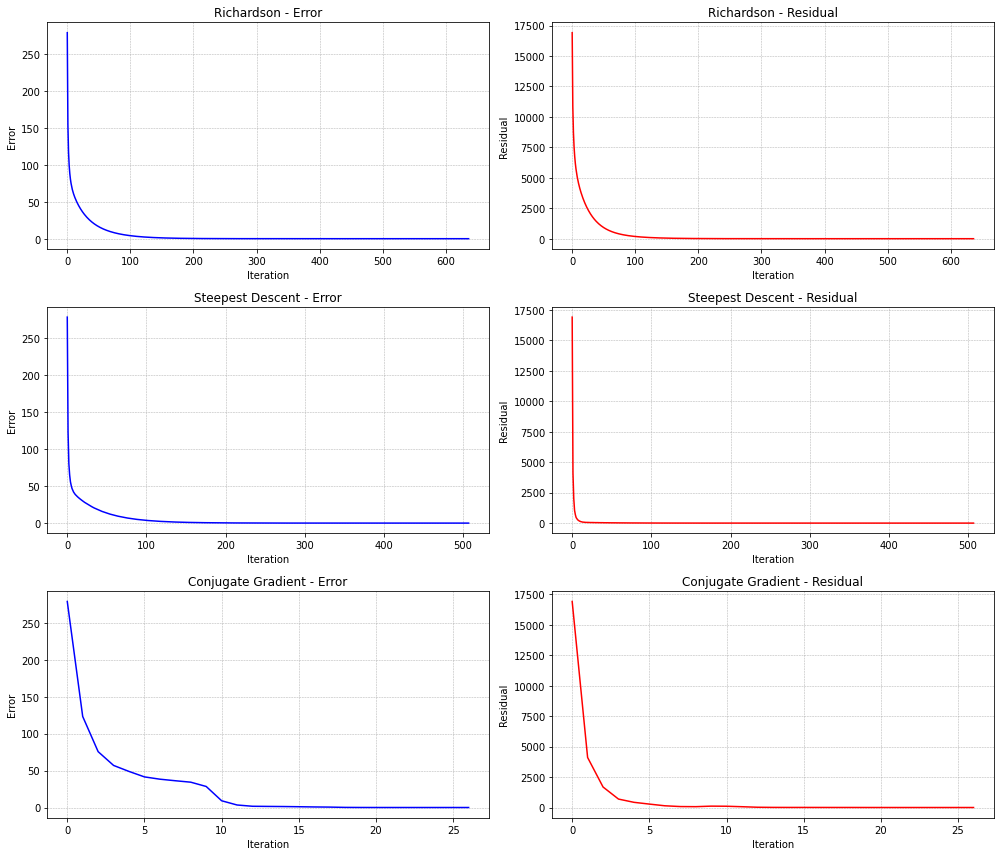

Damping ratio plots saved as 'damping_ratios.png'.


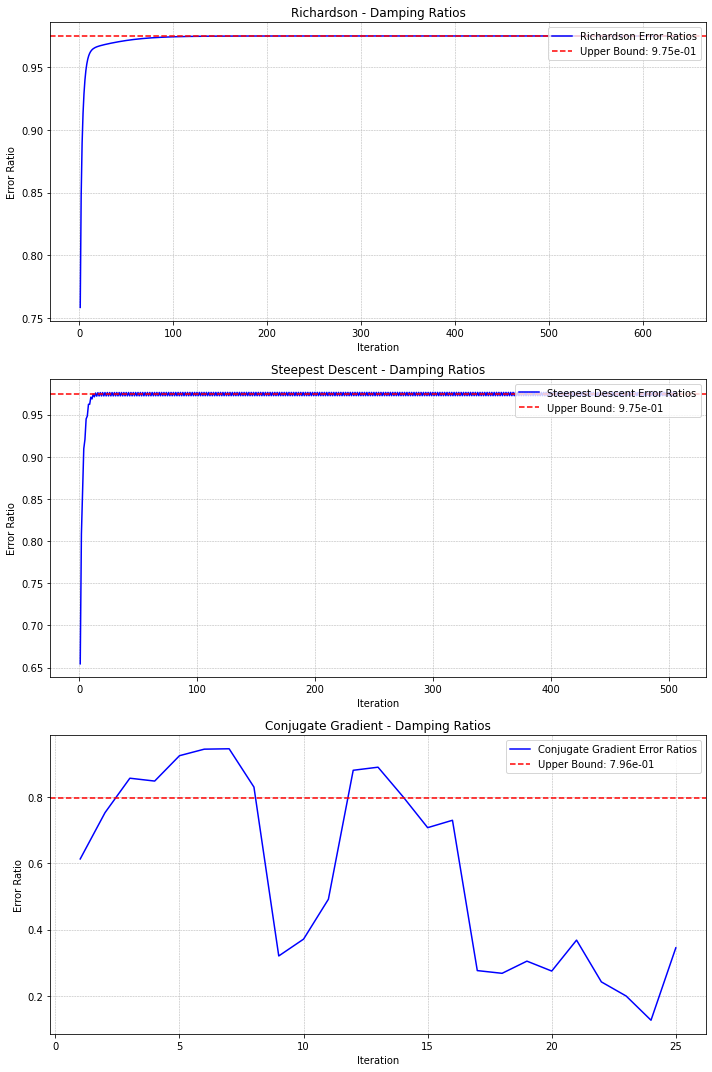

In [255]:
dimension = 100          # This defines work storage = 3*dimension
max_A = 30            # Controlling maximum eigenvalue of the system
min_A = 20              # Has to be > 1 to ensure positive values (A is spd)

A, distinct_values, multiplicities = generate_vector(vector_size=dimension, min_k=30, max_k=40, value_range=(1, 100))
x = generate_random_vector(dimension, -max_A, max_A)

b = A*x

guess = generate_random_vector(dimension, -max_A, max_A)

# Convergence criterion
max_iter = 1000
tol = 1e-08

results = generate_results_and_save_outputs(A, b, guess, x, tol, max_iter, 1)
generate_table_image(distinct_values, multiplicities, output_file="eigenvalues_table.png")

Normal Distribution Cloud Experiment

Condition Number of the System: 5.361691213301816
Spectral Radius of the System: 79.52260363900464
Size of Problem: 100
Tolerance (tol): 1e-08

            Algorithm  Convergence (True/False)  Iterations (num)  \
0          Richardson                      True                48   
1    Steepest Descent                      True                43   
2  Conjugate Gradient                      True                 7   

   Initial Error   Final Error      Residual  Total Work  
0     236.108026  1.808406e-06  1.180373e-04       24202  
1     236.108026  5.645222e-06  1.292328e-04       38957  
2     236.108026  3.176388e-14  4.377845e-14        8099  
Problem information saved as 'problem_info.png'.
Comparison table saved as 'comparison_table.png'.
Grid of convergence plots saved as 'convergence_plots_grid.png'.


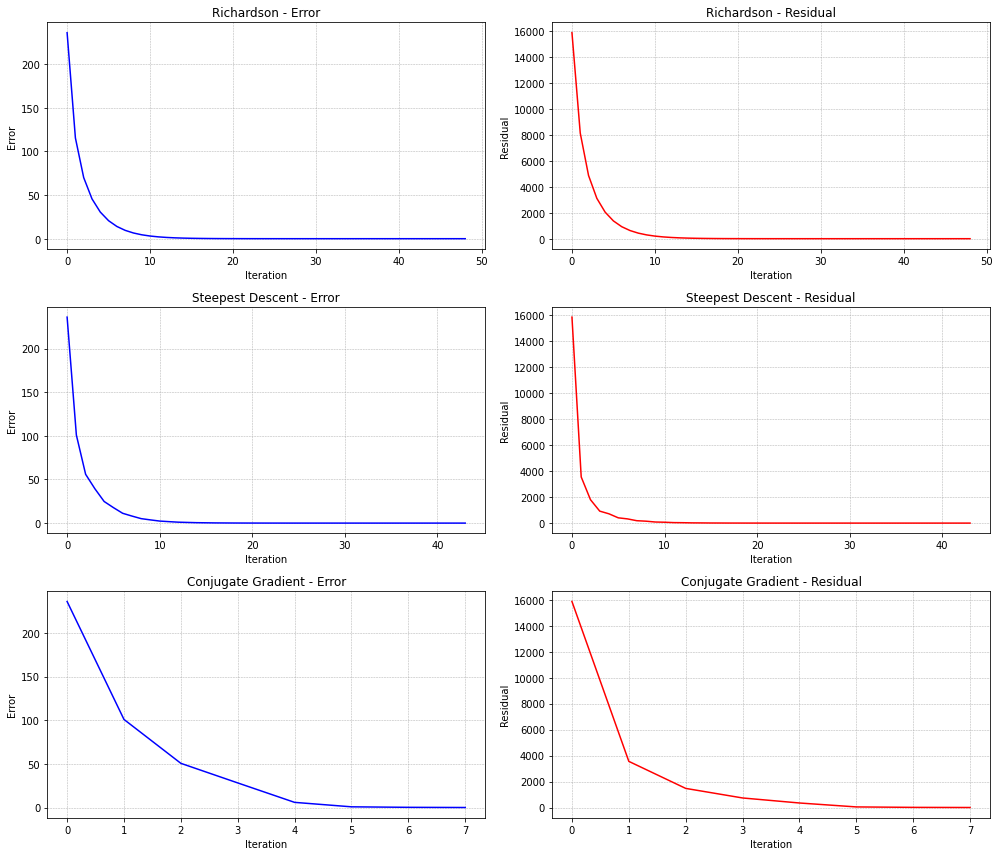

Damping ratio plots saved as 'damping_ratios.png'.


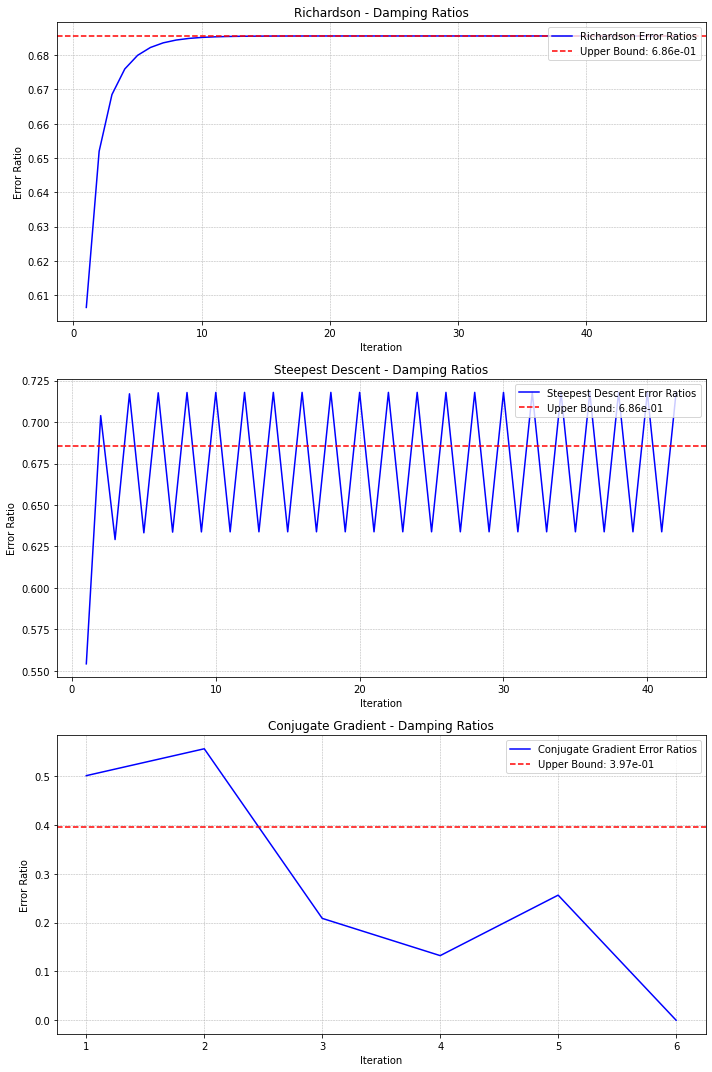

In [ ]:
dimension = 100         # This defines work storage = 3*dimension
max_A = 30            # Controlling maximum eigenvalue of the system
min_A = 20              # Has to be > 1 to ensure positive values (A is spd)

A, distinct_values, multiplicities = generate_vector(vector_size=dimension, min_k=4, max_k=8, value_range=(1, 100))
cloud_vector = generate_cloud_vector(distinct_values, multiplicities, std_dev=0.5)
print(cloud_vector)

x = generate_random_vector(dimension, -max_A, max_A)
b = A*x

guess = generate_random_vector(dimension, -max_A, max_A)

# Convergence criterion
max_iter = 1000
tol = 1e-08

results = generate_results_and_save_outputs(A, b, guess, x, tol, max_iter, 1)
generate_table_image(distinct_values, multiplicities, output_file="eigenvalues_table.png")

Task 2

In [432]:
# Pre-conditioner solvers
def solve_lower(A,b):
    n = len(b)
    c = np.zeros_like(b, dtype=float)
    # Forward substitution: Solve for c in Lc = b
    c[0] = b[0] / A[0][0]
    for i in range(1,n):
        sum_value = 0.0
        for j in range(i):  # Only consider elements below the diagonal
            sum_value += A[i, j] * c[j]
        c[i] = (b[i] - sum_value) / A[i][i]
    return c

def solve_upper(A, c):
    n = len(c)
    x = np.zeros_like(c, dtype=float)
    # Backward substitution: Solve for x in Ux = c
    for i in range(n - 1, -1, -1): # Row index going the opposite way from n-1 to 0
        sum_value = 0.0
        for j in range(i + 1, n):  # Only consider elements to the right of the diagonal
            sum_value += A[i, j] * x[j]
        x[i] = (c[i] - sum_value) / A[i, i]  # Use the diagonal element of U
    return x

def solve_diag(A,c):                # I assume the diagonal part is always dense
    for i in range(len(c)):
        c[i] = c[i] / A[i][i]
    return c

def multiply_diag(A,c):
    for i in range(len(c)):
        c[i] = c[i] * A[i][i]
    return c

def jacobi(A, r_k):                 # The computation is dense regardless of A dense or sparse
    z_k = solve_diag(A, r_k)
    return z_k

def gauss_seidel(A, r_k):
    z_k = solve_lower(A,r_k)
    return z_k
    
def symmetric_gauss_seidel(A, r_k):
    z_k = solve_lower(A, r_k)
    z_k = multiply_diag(A, z_k)
    z_k = solve_upper(A,z_k)
    return z_k

def richardson_sparse(A, b, x_0, precondition = 'None', x_star= None, tol = 10e-06, Max_ITER = 1000):
    x_k = x_0
    r_0 = np.ones_like(x_0)

    r_0 = b - np.matmul(A,x_0)
    r_k = r_0
    errors = np.zeros(Max_ITER+1)
    residuals = np.zeros(Max_ITER+1)
    errors[0] = la.norm(x_0 - x_star)
    residuals[0] = la.norm(r_0)

    num_of_iterations = 0
    while ( ( (la.norm(x_k - x_star))/(la.norm(x_star)) > tol) and num_of_iterations < Max_ITER):
        if(precondition == 'jacobi'):
            z_k = jacobi(A, r_k)
        elif(precondition == 'gauss_seidel'):
            z_k = gauss_seidel(A, r_k)
        elif(precondition == 'symmetric_gauss_seidel'):
            z_k = symmetric_gauss_seidel(A, r_k)
            
        x_k = x_k + z_k
        r_k = r_k - (np.matmul(A,r_k))

        num_of_iterations += 1
        errors[num_of_iterations] = la.norm(x_k - x_star)
        residuals[num_of_iterations] = la.norm(r_k)

    return x_k, num_of_iterations, errors, residuals

In [280]:
examples = [
    np.array([
        [3, 7, -1],
        [7, 4, 1],
        [-1, 1, 2]
    ]),

    np.array([
        [3, 0, 4],
        [7, 4, 2],
        [-1, -1, 2]
    ]),

    np.array([
        [-3, 3, -6],
        [-4, 7, -8],
        [5, 7, -9]
    ]),

    np.array([
        [4, 1, 1],
        [2, -9, 0],
        [0, -8, -6]
    ]),

    np.array([
        [7, 6, 9],
        [4, 5, -4],
        [-7, -3, 8]
    ]),

    np.array([
        [6, -2, 0],
        [-1, 2, -1],
        [0, -6/5, 1]
    ]),

    np.array([
        [5, -1, 0],
        [-1, 2, -1],
        [0, -3/2, 1]
    ]),

    np.array([
        [4, -1, 0, 0, 0, 0, 0],
        [-1, 4, -1, 0, 0, 0, 0],
        [0, -1, 4, -1, 0, 0, 0],
        [0, 0, -1, 4, -1, 0, 0],
        [0, 0, 0, -1, 4, -1, 0],
        [0, 0, 0, 0, -1, 4, -1],
        [0, 0, 0, 0, 0, -1, 4]
    ]),

    np.array([
        [2, -1, 0, 0, 0, 0, 0],
        [-1, 2, -1, 0, 0, 0, 0],
        [0, -1, 2, -1, 0, 0, 0],
        [0, 0, -1, 2, -1, 0, 0],
        [0, 0, 0, -1, 2, -1, 0],
        [0, 0, 0, 0, -1, 2, -1],
        [0, 0, 0, 0, 0, -1, 2]
    ])
]

In [ ]:
def generate_random_matrix(n, min_eigenvalue, max_eigenvalue):
    Q = np.random.rand(n, n)
    Q, _ = np.linalg.qr(Q)  

    eigenvalues = np.random.uniform(min_eigenvalue, max_eigenvalue, n)
    D = np.diag(eigenvalues)
    # Construct symmetric positive-definite matrix
    A = Q @ D @ Q.T
    return A

def compute_iterative_matrices(A):
    n = A.shape[0]
    I = np.eye(n)  # Identity matrix

    # Diagonal matrix D
    D = np.diag(np.diag(A))

    # Lower triangular matrix (including diagonal) D-L
    L = np.tril(A)
    # Upper triangular matrix (including diagonal) D-U
    U = np.triu(A)

    # Jacobi iterative matrix
    G_jacobi = I - inv(D) @ A
    spectral_radius_jacobi = max(abs(eigvals(G_jacobi)))
    norm_jacobi = norm(G_jacobi, 2)
    # Gauss-Seidel iterative matrix
    G_gauss = I - inv(L) @ A
    spectral_radius_gauss = max(abs(eigvals(G_gauss)))
    norm_gauss = norm(G_gauss, 2)

    # Symmetric Gauss-Seidel iterative matrix
    G_symmetric_gauss = I - inv(U) @ D @ inv(L) @ A
    spectral_radius_symmetric_gauss = max(abs(eigvals(G_symmetric_gauss)))
    norm_symmetric_gauss = norm(G_symmetric_gauss, 2)
    return {
        "Jacobi": {"G": G_jacobi, "Spectral Radius": spectral_radius_jacobi, "2-Norm": norm_jacobi},
        "Gauss-Seidel": {"G": G_gauss, "Spectral Radius": spectral_radius_gauss, "2-Norm": norm_gauss},
        "Symmetric Gauss-Seidel": {"G": G_symmetric_gauss, "Spectral Radius": spectral_radius_symmetric_gauss, "2-Norm": norm_symmetric_gauss}
    }

def generate_results_and_table(A, b, guess, x, tol, max_iter, save_outputs=False,
                               convergence_plots="convergence_plots.png",
                               main_table="main_results_table.png",
                               iterative_table="iterative_matrices_table.png"):

    iterative_matrices = compute_iterative_matrices(A)

    # Run Jacobi method
    output_jacobi, num_jacobi, errors_jacobi, residuals_jacobi = richardson_sparse(
        A, b, guess, precondition="jacobi", tol=tol, Max_ITER=max_iter, x_star=x
    )

    # Run Gauss-Seidel method
    output_gs, num_gs, errors_gs, residuals_gs = richardson_sparse(
        A, b, guess, precondition="gauss_seidel", tol=tol, Max_ITER=max_iter, x_star=x
    )
    # Run Symmetric Gauss-Seidel method
    output_sgs, num_sgs, errors_sgs, residuals_sgs = richardson_sparse(
        A, b, guess, precondition="symmetric_gauss_seidel", tol=tol, Max_ITER=max_iter, x_star=x
    )

    main_results = [
        ["Jacobi", num_jacobi < max_iter, num_jacobi, f"{errors_jacobi[0]:.2e}", f"{errors_jacobi[num_jacobi]:.2e}", f"{residuals_jacobi[num_jacobi]:.2e}"],
        ["Gauss-Seidel", num_gs < max_iter, num_gs, f"{errors_gs[0]:.2e}", f"{errors_gs[num_gs]:.2e}", f"{residuals_gs[num_gs]:.2e}"],
        ["Symmetric Gauss-Seidel", num_sgs < max_iter, num_sgs, f"{errors_sgs[0]:.2e}", f"{errors_sgs[num_sgs]:.2e}", f"{residuals_sgs[num_sgs]:.2e}"],
    ]

    main_results_df = pd.DataFrame(
        main_results,
        columns=[
            "Algorithm",
            "Convergence (True/False)",
            "Iterations (num)",
            "Initial Error",
            "Final Error",
            "Final Residual"
        ]
    )

    iterative_results = [
        ["Jacobi", iterative_matrices["Jacobi"]["Spectral Radius"], iterative_matrices["Jacobi"]["2-Norm"]],
        ["Gauss-Seidel", iterative_matrices["Gauss-Seidel"]["Spectral Radius"], iterative_matrices["Gauss-Seidel"]["2-Norm"]],
        ["Symmetric Gauss-Seidel", iterative_matrices["Symmetric Gauss-Seidel"]["Spectral Radius"], iterative_matrices["Symmetric Gauss-Seidel"]["2-Norm"]],
    ]

    iterative_results_df = pd.DataFrame(
        iterative_results,
        columns=[
            "Algorithm",
            "Spectral Radius",
            "2-Norm"
        ]
    )

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))

    methods = [
        ("Jacobi", num_jacobi, errors_jacobi, residuals_jacobi),
        ("Gauss-Seidel", num_gs, errors_gs, residuals_gs),
        ("Symmetric Gauss-Seidel", num_sgs, errors_sgs, residuals_sgs)
    ]

    for i, (method, num, errors, residuals) in enumerate(methods):
        # Plot errors
        axes[i, 0].plot(range(num + 1), errors[:num + 1], label=f"{method} - Error", color="blue")
        axes[i, 0].set_title(f"{method} - Error")
        axes[i, 0].set_xlabel("Iteration")
        axes[i, 0].set_ylabel("Error")
        axes[i, 0].grid(True, linestyle="--", linewidth=0.5)
        axes[i, 0].legend()

        # Plot residuals
        axes[i, 1].plot(range(num + 1), residuals[:num + 1], label=f"{method} - Residual", color="red")
        axes[i, 1].set_title(f"{method} - Residual")
        axes[i, 1].set_xlabel("Iteration")
        axes[i, 1].set_ylabel("Residual")
        axes[i, 1].grid(True, linestyle="--", linewidth=0.5)
        axes[i, 1].legend()

    plt.tight_layout()

    if save_outputs:
        # Save convergence plots
        plt.savefig(convergence_plots, bbox_inches="tight")
        print(f"Convergence plots saved as '{convergence_plots}'.")
        plt.close()
    else:
        plt.show()

    if save_outputs:

        fig, ax = plt.subplots(figsize=(14, 6)) 
        ax.axis("tight")
        ax.axis("off")
        table = ax.table(cellText=main_results_df.values, colLabels=main_results_df.columns, cellLoc="center", loc="center")
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        plt.savefig(main_table, bbox_inches="tight")
        print(f"Main results table saved as '{main_table}'.")
        plt.close()

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.axis("tight")
        ax.axis("off")
        table = ax.table(cellText=iterative_results_df.values, colLabels=iterative_results_df.columns, cellLoc="center", loc="center")
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        plt.savefig(iterative_table, bbox_inches="tight")
        print(f"Iterative matrices table saved as '{iterative_table}'.")
        plt.close()

    return main_results_df, iterative_results_df


In [433]:
A = examples[4]  #
n = np.shape(A)[1]

iterative_matrices = compute_iterative_matrices(A)   
x = generate_random_vector(n, 0, 0)
guess = generate_random_vector(n, 1,1)
b = np.matmul(A,x)

tol = 10e-06
max_iter = 1000
main_df, iterative_df = generate_results_and_table(
    A, b, guess, x, tol, max_iter, save_outputs=True
)

C:\Users\DELL\AppData\Local\Temp\ipykernel_15212\3647309142.py:61: RuntimeWarning: divide by zero encountered in double_scalars
  while ( ( (la.norm(x_k - x_star))/(la.norm(x_star)) > tol) and num_of_iterations < Max_ITER):


Convergence plots saved as 'convergence_plots.png'.
Main results table saved as 'main_results_table.png'.
Iterative matrices table saved as 'iterative_matrices_table.png'.


In [ ]:
def generate_sparse_positive_definite_matrix(n, max_nonzeros_row=3, value_range=(0.1, 1.0)):
    diagonal = np.random.uniform(value_range[0] * 10, value_range[1] * 10, n)

    L = np.zeros((n, n))
    for i in range(1, n):
        num_nonzeros = np.random.randint(1, min(max_nonzeros_row + 1, i + 1))
        col_indices = np.random.choice(range(i), size=num_nonzeros, replace=False)
        L[i, col_indices] = np.random.uniform(value_range[0], value_range[1], num_nonzeros)

    A = L + L.T + np.diag(diagonal)

    for i in range(n):
        off_diagonal_sum = np.sum(np.abs(A[i, :])) - np.abs(A[i, i])
        if A[i, i] <= off_diagonal_sum:
            A[i, i] = off_diagonal_sum + np.random.uniform(0.1, 1.0)

    csr = csr_matrix(A)

    return A, csr

def generate_table_image(distinct_values, multiplicities, output_file="table.png"):
    data = {
        "Eigenvalue": distinct_values,
        "Multiplicity": multiplicities
    }
    df = pd.DataFrame(data)


    fig, ax = plt.subplots(figsize=(6, len(distinct_values) * 0.5 + 1))
    ax.axis('tight')
    ax.axis('off')

    table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(len(df.columns))))

    plt.savefig(output_file, bbox_inches='tight')
    plt.close()


Generated Sparse Positive Definite Matrix:
[[7.49552515 0.85723342 0.11396355 0.         0.         0.2716876
  0.11129471 0.         0.37077725 0.        ]
 [0.85723342 7.61736291 0.16122981 0.15433764 0.75079334 0.
  0.         0.         0.         0.        ]
 [0.11396355 0.16122981 2.13392511 0.65235893 0.         0.
  0.         0.29276549 0.         0.        ]
 [0.         0.15433764 0.65235893 8.6474447  0.         0.
  0.48090826 0.         0.69814133 0.        ]
 [0.         0.75079334 0.         0.         1.22479074 0.
  0.         0.16176869 0.         0.        ]
 [0.2716876  0.         0.         0.         0.         7.74959243
  0.         0.90135292 0.         0.        ]
 [0.11129471 0.         0.         0.48090826 0.         0.
  7.06329296 0.         0.         0.        ]
 [0.         0.         0.29276549 0.         0.16176869 0.90135292
  0.         5.47017522 0.76138609 0.33360762]
 [0.37077725 0.         0.         0.69814133 0.         0.
  0.         0.761

Task 3

In [ ]:
def solve_lower_sparse(A, b):
    n = len(b)
    c = np.zeros_like(b, dtype=float)
    for i in range(n):
        sum_value = 0.0
        row_start = A.indptr[i]
        row_end = A.indptr[i + 1]
        for j_idx in range(row_start, row_end):
            col = A.indices[j_idx]
            if col >= i:
                break
            sum_value += A.data[j_idx] * c[col]
        c[i] = (b[i] - sum_value) / A[i, i]
    return c

def solve_upper_sparse(A, c):
    n = len(c)
    x = np.zeros_like(c, dtype=float)
    for i in range(n - 1, -1, -1):
        sum_value = 0.0
        row_start = A.indptr[i]
        row_end = A.indptr[i + 1]
        for j_idx in range(row_end - 1, row_start - 1, -1):
            col = A.indices[j_idx]
            if col <= i:
                continue
            sum_value += A.data[j_idx] * x[col]
        x[i] = (c[i] - sum_value) / A[i, i]
    return x

def sparse_matmul(A, x):
    return A.dot(x)

def solve_diag_sparse(A, c):
    for i in range(len(c)):
        c[i] = c[i] / A[i, i]
    return c

def multiply_diag_sparse(A, c):
    for i in range(len(c)):
        c[i] = c[i] * A[i, i]
    return c

def jacobi_sparse(A, r_k):
    z_k = solve_diag_sparse(A, r_k)
    return z_k

def gauss_seidel_sparse(A, r_k):
    z_k = solve_lower_sparse(A, r_k)
    return z_k

def symmetric_gauss_seidel_sparse(A, r_k):
    z_k = solve_lower_sparse(A, r_k)
    z_k = multiply_diag_sparse(A, z_k)
    z_k = solve_upper_sparse(A, z_k)
    return z_k

def richardson_sparse_final(A, b, x_0, precondition='None', x_star=None, tol=1e-6, Max_ITER=1000):
    x_k = x_0
    r_0 = b - sparse_matmul(A, x_0)
    r_k = r_0
    errors = np.zeros(Max_ITER + 1)
    residuals = np.zeros(Max_ITER + 1)
    errors[0] = la.norm(x_0 - x_star)
    residuals[0] = la.norm(r_0)

    num_of_iterations = 0
    while ((la.norm(x_k - x_star) / la.norm(x_star) > tol) and num_of_iterations < Max_ITER):
        if precondition == 'jacobi':
            z_k = jacobi_sparse(A, r_k)
        elif precondition == 'gauss_seidel':
            z_k = gauss_seidel_sparse(A, r_k)
        elif precondition == 'symmetric_gauss_seidel':
            z_k = symmetric_gauss_seidel_sparse(A, r_k)
        
        x_k = x_k + z_k
        r_k = r_k - sparse_matmul(A, z_k)

        num_of_iterations += 1
        errors[num_of_iterations] = la.norm(x_k - x_star)
        residuals[num_of_iterations] = la.norm(r_k)

    return x_k, num_of_iterations, errors[:num_of_iterations], residuals[:num_of_iterations]
